# Model Comparisons

This notebook summarizes and compares the three supervised learning models trained for grain disease classification on the GrainSet dataset (Rice and Maize only).

The three models evaluated are:
1. **Logistic Regression** - baseline linear classifier using HSV histogram features
2. **Support Vector Machine (SVM)** - non-linear classifier with RBF kernel using HSV histogram features
3. **EfficientNetV2-Small (CNN)** - fine-tuned pre-trained deep learning model using raw image pixels

All models are evaluated on the same held-out test set of **4,500 images** (1,600 maize + 2,900 rice) across **14 classes**.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

## Overall Performance Summary

The table below shows the top-level metrics for each model on the test set. All scores are weighted averages to account for class imbalance (the normal grain classes have significantly more samples than disease classes).

In [2]:
# Overall metrics from each model's test run
summary_data = {
    'Model': [
        'Logistic Regression',
        'SVM (RBF Kernel)',
        'EfficientNetV2-Small (CNN)'
    ],
    'Feature Type': [
        'HSV Histogram (512-dim)',
        'HSV Histogram (512-dim)',
        'Raw Pixels (384x384)'
    ],
    'Best Hyperparameters': [
        'C=1, penalty=l2, solver=lbfgs',
        'C=100, kernel=rbf, gamma=scale',
        'lr=9.12e-6, epochs=39, label_smoothing'
    ],
    'CV F1 (Weighted)': [0.8879, 0.8949, None],
    'Test Accuracy': [0.8704, 0.8811, 0.9882],
    'Test F1 (Weighted)': [0.8685, 0.8817, None],
    'Test F1 (Macro)': [0.7481, 0.7743, 0.9820],
    'Test Precision (Macro)': [0.7681, 0.7931, 0.9779],
    'Test Recall (Macro)': [0.7390, 0.7696, 0.9870],
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Model')

print("OVERALL MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(summary_df.to_string())

OVERALL MODEL PERFORMANCE SUMMARY
                                       Feature Type                    Best Hyperparameters  CV F1 (Weighted)  Test Accuracy  Test F1 (Weighted)  Test F1 (Macro)  Test Precision (Macro)  Test Recall (Macro)
Model                                                                                                                                                                                                         
Logistic Regression         HSV Histogram (512-dim)           C=1, penalty=l2, solver=lbfgs            0.8879         0.8704              0.8685           0.7481                  0.7681               0.7390
SVM (RBF Kernel)            HSV Histogram (512-dim)          C=100, kernel=rbf, gamma=scale            0.8949         0.8811              0.8817           0.7743                  0.7931               0.7696
EfficientNetV2-Small (CNN)     Raw Pixels (384x384)  lr=9.12e-6, epochs=39, label_smoothing               NaN         0.9882              

## Accuracy and F1 Score Comparison

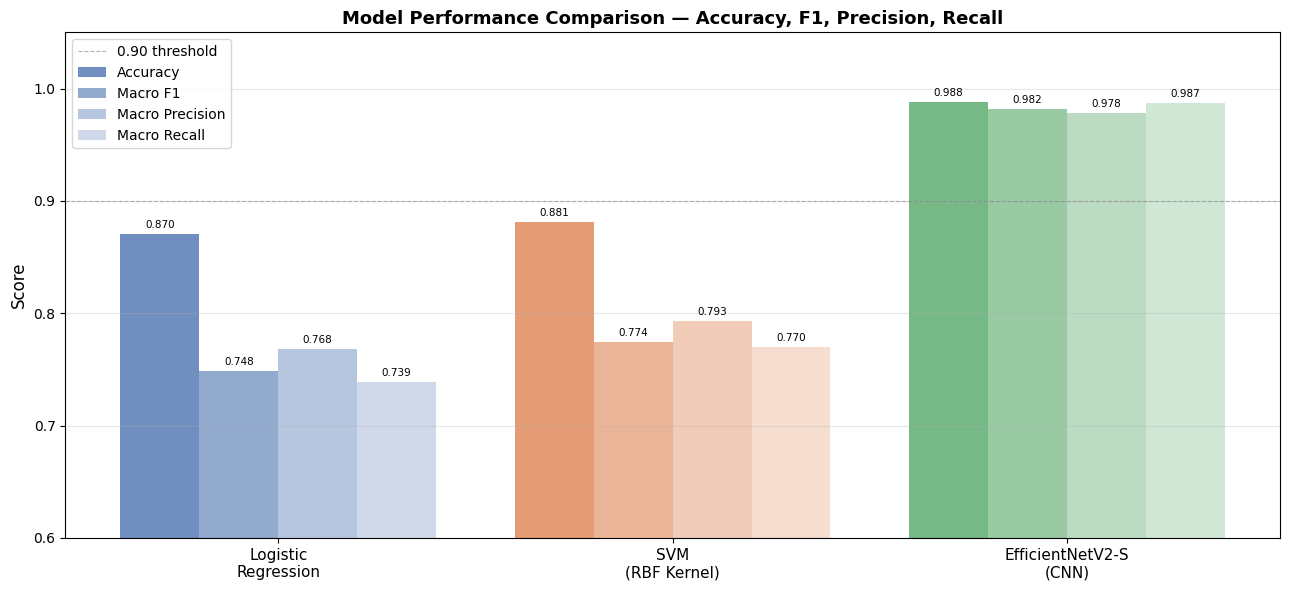

In [3]:
models = ['Logistic\nRegression', 'SVM\n(RBF Kernel)', 'EfficientNetV2-S\n(CNN)']
colors = ['#4C72B0', '#DD8452', '#55A868']

accuracy   = [0.8704, 0.8811, 0.9882]
f1_macro   = [0.7481, 0.7743, 0.9820]
precision  = [0.7681, 0.7931, 0.9779]
recall     = [0.7390, 0.7696, 0.9870]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',        color=[c + 'CC' for c in ['#4C72B0','#DD8452','#55A868']])
bars2 = ax.bar(x - 0.5*width, f1_macro,  width, label='Macro F1',        color=[c + '99' for c in ['#4C72B0','#DD8452','#55A868']])
bars3 = ax.bar(x + 0.5*width, precision, width, label='Macro Precision',  color=[c + '66' for c in ['#4C72B0','#DD8452','#55A868']])
bars4 = ax.bar(x + 1.5*width, recall,    width, label='Macro Recall',     color=[c + '44' for c in ['#4C72B0','#DD8452','#55A868']])

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — Accuracy, F1, Precision, Recall', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.6, 1.05)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='0.90 threshold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Per-Class F1 Score Comparison

The overall metrics can be misleading due to class imbalance. 
The two normal classes (`maize_0_NOR`, `rice_0_NOR`) dominate the test set. The per-class breakdown reveals how each model actually handles the disease categories that matter most for practical grain quality inspection.

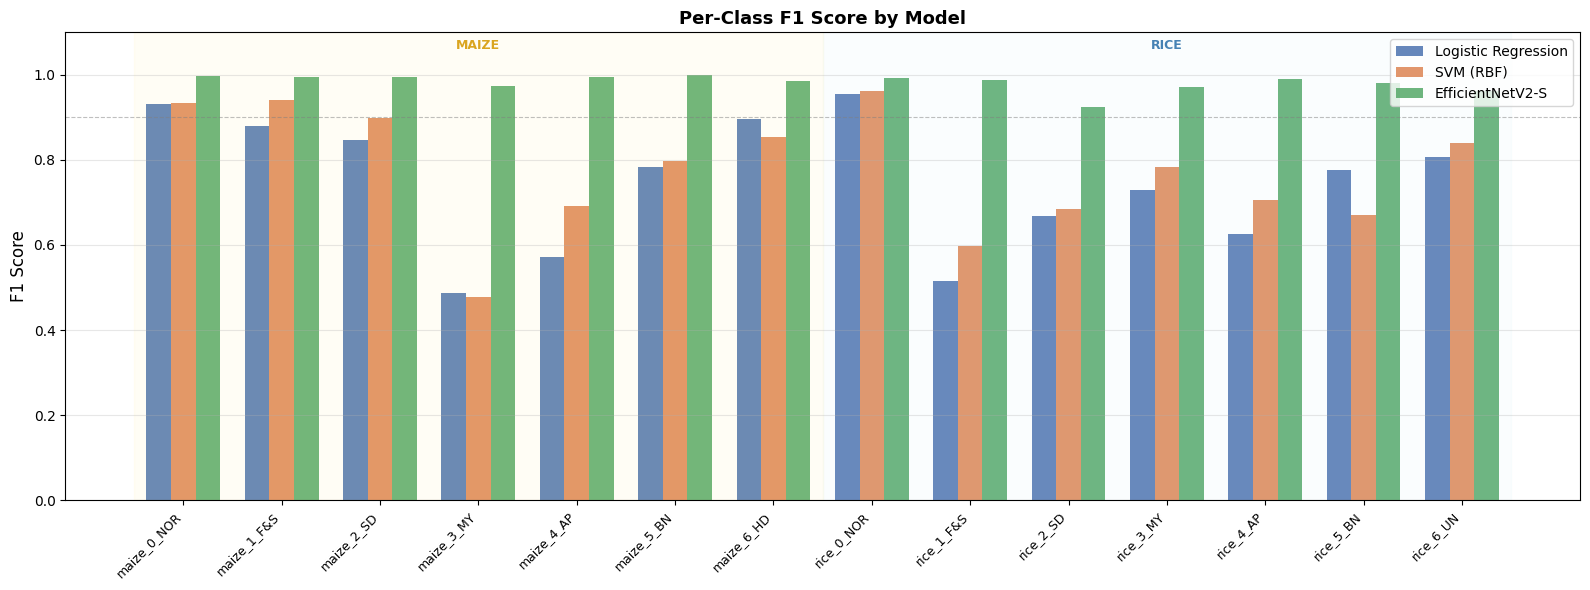

In [4]:
classes = [
    'maize_0_NOR', 'maize_1_F&S', 'maize_2_SD', 'maize_3_MY',
    'maize_4_AP',  'maize_5_BN',  'maize_6_HD',
    'rice_0_NOR',  'rice_1_F&S',  'rice_2_SD',  'rice_3_MY',
    'rice_4_AP',   'rice_5_BN',   'rice_6_UN'
]

# Per-class F1 from classification reports
lr_f1 = [0.9316, 0.8788, 0.8478, 0.4872, 0.5714, 0.7843, 0.8958,
          0.9559, 0.5155, 0.6689, 0.7298, 0.6258, 0.7754, 0.8059]

svm_f1 = [0.9350, 0.9406, 0.8995, 0.4774, 0.6916, 0.7978, 0.8539,
           0.9621, 0.5981, 0.6844, 0.7838, 0.7069, 0.6705, 0.8389]

cnn_f1 = [0.9980, 0.9950, 0.9950, 0.9746, 0.9950, 1.0000, 0.9848,
           0.9917, 0.9868, 0.9255, 0.9705, 0.9899, 0.9799, 0.9610]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x - width, lr_f1,  width, label='Logistic Regression', color='#4C72B0', alpha=0.85)
ax.bar(x,         svm_f1, width, label='SVM (RBF)',            color='#DD8452', alpha=0.85)
ax.bar(x + width, cnn_f1, width, label='EfficientNetV2-S',     color='#55A868', alpha=0.85)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score by Model', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Shade maize vs rice regions
ax.axvspan(-0.5, 6.5, alpha=0.04, color='gold', label='Maize')
ax.axvspan(6.5, 13.5, alpha=0.04, color='skyblue', label='Rice')
ax.text(3, 1.06, 'MAIZE', ha='center', fontsize=9, color='goldenrod', fontweight='bold')
ax.text(10, 1.06, 'RICE', ha='center', fontsize=9, color='steelblue', fontweight='bold')

plt.tight_layout()
plt.show()

## The Hardest Classes: A Closer Look

Two classes were consistently the most difficult across all classical models: `maize_3_MY` (Moldy) and `rice_1_F&S` (Fungal & Stained). These are highlighted below to track how each model handles them.

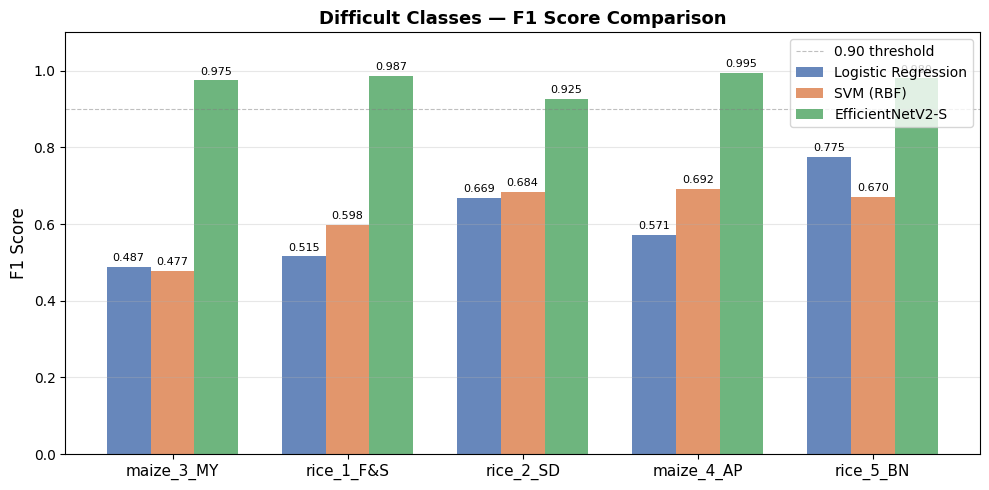


Observation: The CNN performs better in every difficult class.
maize_3_MY went from ~0.48 (LR/SVM) to 0.975 (CNN) : a +0.49 improvement.
rice_1_F&S went from 0.52–0.60 (LR/SVM) to 0.987 (CNN) : a +0.39 improvement.


In [5]:
hard_classes = ['maize_3_MY', 'rice_1_F&S', 'rice_2_SD', 'maize_4_AP', 'rice_5_BN']

hard_lr  = [0.4872, 0.5155, 0.6689, 0.5714, 0.7754]
hard_svm = [0.4774, 0.5981, 0.6844, 0.6916, 0.6705]
hard_cnn = [0.9746, 0.9868, 0.9255, 0.9950, 0.9799]

x = np.arange(len(hard_classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, hard_lr,  width, label='Logistic Regression', color='#4C72B0', alpha=0.85)
ax.bar(x,         hard_svm, width, label='SVM (RBF)',            color='#DD8452', alpha=0.85)
ax.bar(x + width, hard_cnn, width, label='EfficientNetV2-S',     color='#55A868', alpha=0.85)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Difficult Classes — F1 Score Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(hard_classes, fontsize=11)
ax.set_ylim(0, 1.1)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='0.90 threshold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bars, vals in zip([x - width, x, x + width], [hard_lr, hard_svm, hard_cnn]):
    for xi, v in zip(bars, vals):
        ax.text(xi, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nObservation: The CNN performs better in every difficult class.")
print("maize_3_MY went from ~0.48 (LR/SVM) to 0.975 (CNN) : a +0.49 improvement.")
print("rice_1_F&S went from 0.52–0.60 (LR/SVM) to 0.987 (CNN) : a +0.39 improvement.")

## Model Improvement Trajectory

How much did each upgrade actually help? This tracks the accuracy and macro F1 improvement across models.

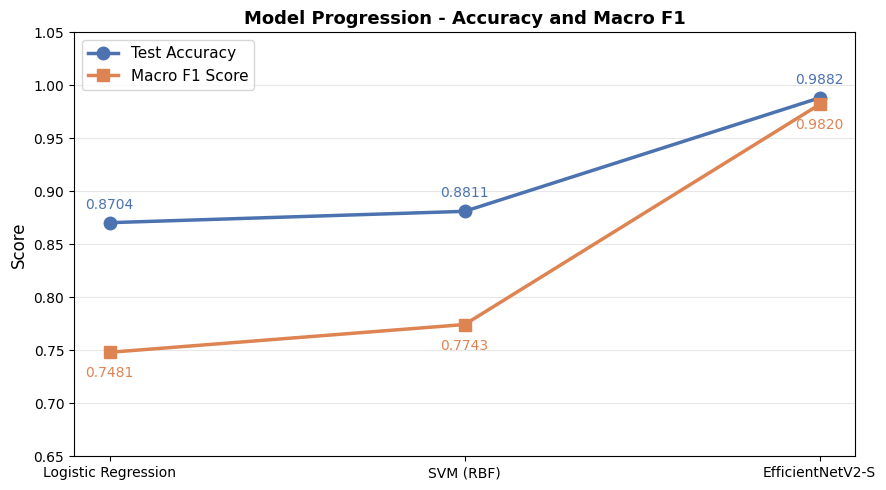

In [6]:
model_names = ['Logistic Regression', 'SVM (RBF)', 'EfficientNetV2-S']
test_acc   = [0.8704, 0.8811, 0.9882]
macro_f1   = [0.7481, 0.7743, 0.9820]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(model_names, test_acc, marker='o', linewidth=2.5, markersize=9,
        color='#4C72B0', label='Test Accuracy')
ax.plot(model_names, macro_f1, marker='s', linewidth=2.5, markersize=9,
        color='#DD8452', label='Macro F1 Score')

for i, (a, f) in enumerate(zip(test_acc, macro_f1)):
    ax.annotate(f'{a:.4f}', (model_names[i], a), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10, color='#4C72B0')
    ax.annotate(f'{f:.4f}', (model_names[i], f), textcoords='offset points',
                xytext=(0, -18), ha='center', fontsize=10, color='#DD8452')

ax.set_ylim(0.65, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Progression - Accuracy and Macro F1', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Key Takeaways

### Model-by-Model Summary

**Logistic Regression (Baseline)**  
Accuracy: 0.8704 | Macro F1: 0.7481

- Best hyperparameters: `C=1, penalty=l2, no class weighting`
- Strong on majority classes (`maize_0_NOR`: 0.9316, `rice_0_NOR`: 0.9559)
- Struggled with minority disease classes, especially `maize_3_MY` (F1: 0.4872) and `rice_1_F&S` (F1: 0.5155)
- The gap between weighted F1 (0.8685) and macro F1 (0.7481) shows that the good overall score is carried by large normal classes
- Note: linear decision boundaries on color-only features cannot separate visually similar disease categories


**Support Vector Machine - RBF Kernel**  
Accuracy: 0.8811 | Macro F1: 0.7743

- Best hyperparameters: `C=100, kernel=rbf, gamma=scale, no class weighting`
- Outperformed Logistic Regression on nearly every class - the RBF kernel's curved boundaries helped
- Did better on `maize_4_AP` (+0.12), `maize_1_F&S` (+0.06), and `rice_3_MY` (+0.05)
- `maize_3_MY` remained the hardest class (F1: 0.4774) - even a more powerful model couldn't solve the color feature limitation
- Note: the upgrade from LR to SVM helped, but the limitation was the feature representation, not the classifier


**EfficientNetV2-Small (Fine-tuned CNN)**  
Accuracy: 0.9882 | Macro F1: 0.9820

- Architecture: EfficientNetV2-S pretrained on ImageNet, last 3 blocks fine-tuned, classifier head replaced for 14 classes
- Training: 39 epochs, CosineAnnealing LR scheduler, label smoothing, weighted sampler for class imbalance
- Did better with the color limitation: `maize_3_MY` (F1: 0.9746) and `rice_1_F&S` (F1: 0.9868)
- Weakest class was `rice_2_SD` (F1: 0.9255) but still did better than the classical model performance
- Grad-CAM analysis of false positives revealed that the model may have learned a feature representation for rice_2_SD that was too broad, flagging rice_0_NOR grains as sporuted.
- Note: macro F1 (0.9820) vs. test accuracy (0.9882), indicating consistent performance across all classes


### Why Did the CNN Win by Such a Wide Margin?

The classical models were limited by their feature representation. Both used a 512-dimensional HSV color histogram, encoding *what colors exist* in the image but not taking into account their *location and texture*. Disease patterns like mold or staining may share similar color profiles across categories, making them inseparable by any classifier working on color alone.

EfficientNetV2 works directly on raw pixels. Its convolutional layers learn features (spatial patterns edges, textures, surface damage) that are invisible to HSV histograms. This is why it recovered on every class that the classical models failed on.


### Recommendations for Future Work

- For classical models, adding **HOG (Histogram of Oriented Gradients)** or **LBP (Local Binary Patterns)** texture features alongside the HSV histogram could close the gap on difficult texture-based disease classes
- The CNN's only weak point was `rice_2_SD` - additional augmentation or targeted oversampling for that class could help performance
- Deploying the CNN in a real-world grain inspection pipeline is feasible given its 98.8% accuracy on test data